## TripletSemihardLoss


To implement the BNNeck for simultaneous Triplet and ID (Classification) loss, we need to modify the model to return two outputs: the features before the BN layer (for Triplet Loss) and the predictions after the BN layer (for ID Loss).

In the "Strong Baseline" paper, the Triplet Loss is calculated on the unnormalized features to preserve the Euclidean distances, while the Softmax loss is calculated on normalized features to improve convergence.

# Updated Model with Dual Outputs
Here is how you can restructure your build_constraint_gem_cnn function to support this:

# Handling the Losses during Training
Because the model now has two outputs, you must define a custom training step or use a dictionary in model.compile. Here is the logic for balancing the losses:

## Total Loss
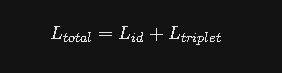



# Inference Logic:
During evaluation, we are interested in the ID (classification) performance. The BNNeck architecture calculates this ID loss after the Batch Normalization layer to ensure the features are centered on a hypersphere


# Why this works
## Metric Stability:
The global_feat (pre-BN) contains the raw magnitude of the activations, which Triplet Loss uses to pull similar images together and push different ones apart.

## Classification Convergence:
The bn_feat (post-BN) ensures that the input to the final Dense layer is normalized. This prevents the "gradient vanishing" or "gradient explosion" issues that often occur when trying to satisfy both Triplet and Softmax losses simultaneously.

# Analysis of Training Progress
## Total Loss:
This is the sum of your two weighted losses (1.0 x Triplet + 1.0 x ID Loss).
## gem_features_loss:
This represents the Triplet Semi-Hard Loss. A value around 0.3 suggests the model is finding "semi-hard" triplets and successfully pushing the negative samples outside the margin (0.3 in the normalized Euclidean space.# ##id_loss_output_loss:
This is the Sparse Categorical Crossentropy from the BNNeck.
## id_loss_output_accuracy:
This is the classification accuracy on the EMNIST digits using the features after the Batch Normalization layer.


# Architecture Alignment Check
According to your model_architecture.png, the flow should be a single backbone that splits only after the Generalized Mean (GeM) pooling layer. Based on your successful load, here is how the branches are now structured:

Common Backbone: All layers up to raw_gem_embedding_layer.
## Branch 1 (Metric):
raw_gem_embedding_layer $rightarrow$ gem_features (L2NormalizeLayer) $\rightarrow$ Triplet Loss
## Branch 2 (Classification):
raw_gem_embedding_layer $\rightarrow$ bn_neck (BatchNormalization) $\rightarrow$ id_loss_output (Dense) $\rightarrow$ ID Loss


Path to dataset files: /root/.cache/kagglehub/datasets/osamaaslam86004/emnist-digits-balanced/versions/1
--- Loading EMNIST Digits from local PNG folders ---
Found 240000 files belonging to 10 classes.
Using 192000 files for training.
Found 240000 files belonging to 10 classes.
Using 48000 files for validation.
Found 40000 files belonging to 10 classes.
Class names: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 1)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ preprocessing_head  │ (None, None,      │          3 │ input_layer_2[0]… │
│ (Sequential)        │ None, 1)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, None,      │        160 │ preprocessing_he… │
│                     │ None, 16)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, None,      │      4,640 │ conv2d_3[0][0]    │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, None,      │     18,496 │ conv2d_4[0][0]    │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ raw_gem_embedding_… │ (None, 64)        │         64 │ conv2d_5[0][0]    │
│ (GeMPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_neck             │ (None, 64)        │        256 │ raw_gem_embeddin… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gem_features        │ (None, 64)        │          0 │ raw_gem_embeddin… │
│ (L2NormalizeLayer)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ id_loss_output      │ (None, 10)        │        640 │ bn_neck[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,259 (94.77 KB)

 Trainable params: 24,128 (94.25 KB)

 Non-trainable params: 131 (528.00 B)

1498/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - gem_features_loss: 0.3070 - id_loss_output_accuracy: 0.7324 - id_loss_output_loss: 0.8529 - loss: 1.1599
Epoch 1: val_id_loss_output_accuracy improved from None to 0.41598, saving model to emnist_best_model.keras

Epoch 1: finished saving model to emnist_best_model.keras
 - Epoch 1 Time: 50.87s | Throughput: 3774.23 img/sec
 - Epoch 1 Shift Consistency (1px): 94.05%
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 114s 64ms/step - gem_features_loss: 0.3039 - id_loss_output_accuracy: 0.8407 - id_loss_output_loss: 0.5289 - loss: 0.8327 - val_gem_features_loss: 0.3013 - val_id_loss_output_accuracy: 0.4160 - val_id_loss_output_loss: 2.4424 - val_loss: 2.7437 - val_shift_consistency: 0.9405
Restoring model weights from the end of the best epoch: 1.

--- Starting Latency Measurement (100 iterations) ---
Average Inference Latency: 78.86 ms
P95 Latency (Tail Latency): 114.97 ms
Classification Report (Test Set):
              precision    recall  f1-score   support



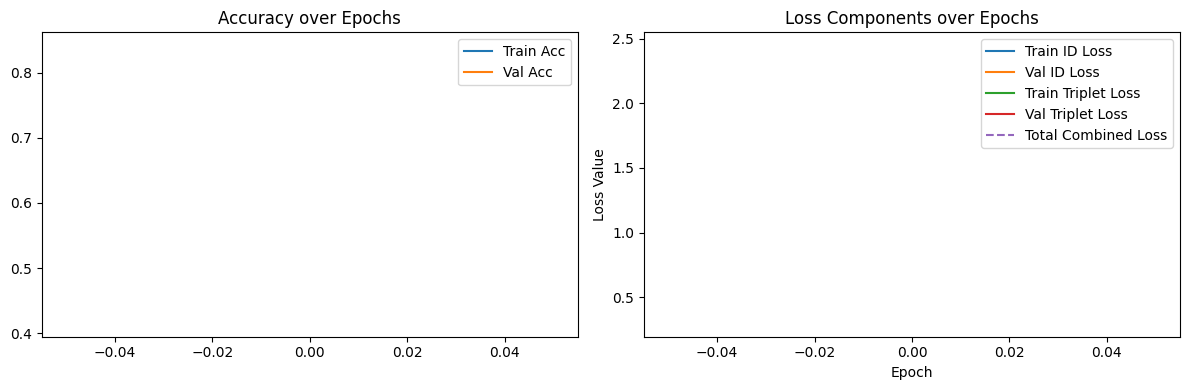

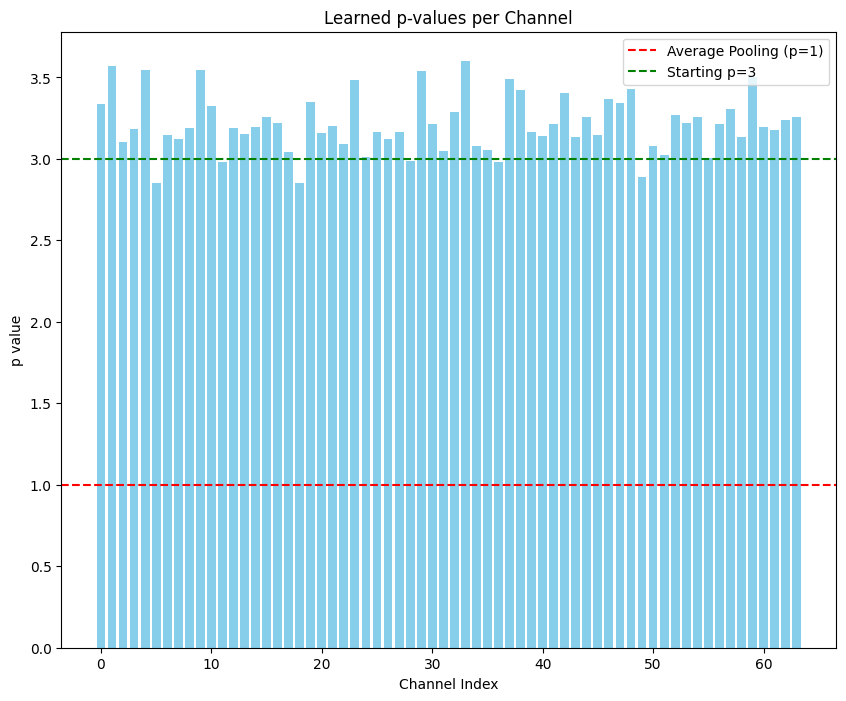

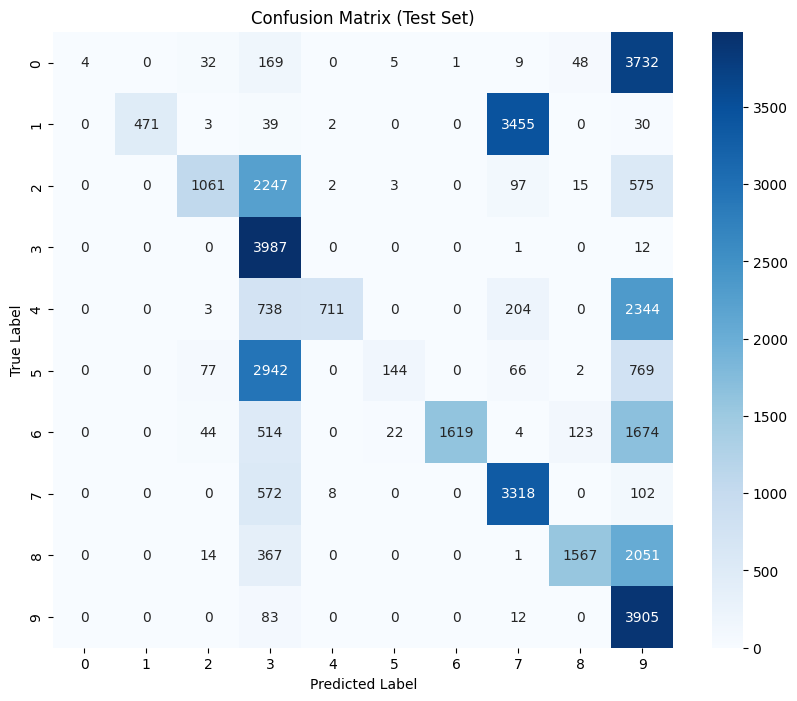

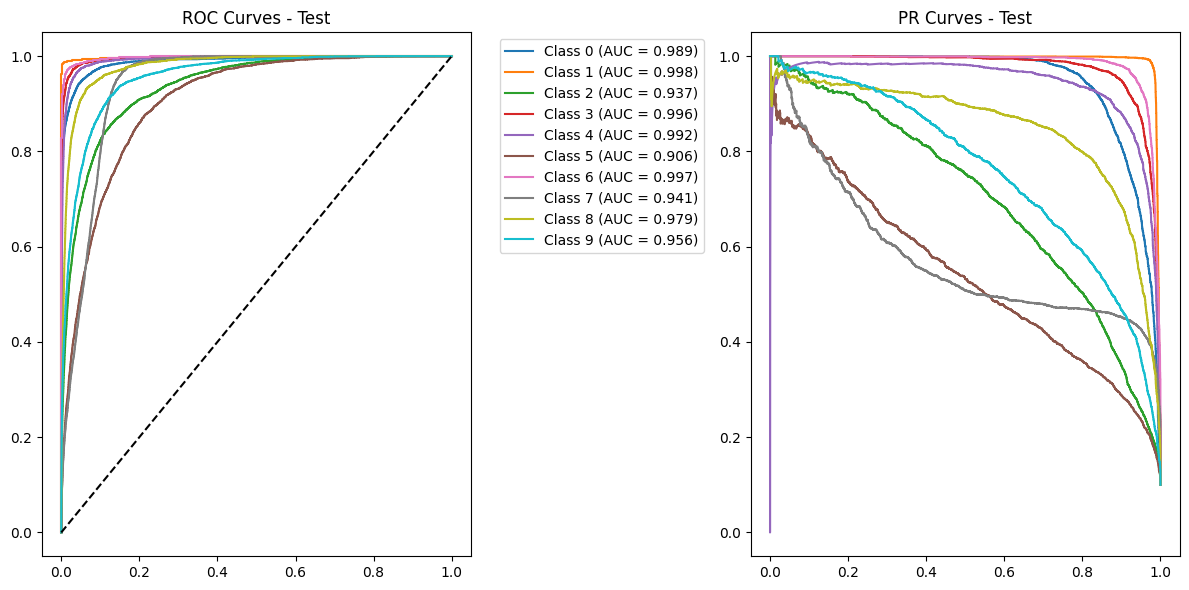

In [4]:
import time
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, regularizers, backend, losses
from tensorflow.keras.utils import plot_model # Added plot_model
from sklearn.metrics import (roc_curve, auc, precision_recall_curve,
                             average_precision_score, confusion_matrix,
                             classification_report, accuracy_score)
from sklearn.preprocessing import label_binarize
import kagglehub

# Download latest version
path = kagglehub.dataset_download("osamaaslam86004/emnist-digits-balanced")

print("Path to dataset files:", path)
DATA_DIR = path

# Download latest version
# DATA_DIR = "/kaggle/input/emnist-digits-balanced"

# Global access and constants
IMG_SIZE = (28, 28)
BATCH_SIZE = 128
SEED = 42

def get_keras_dataset():
    print("--- Loading EMNIST Digits from local PNG folders ---")

    # Global access and constants
    global IMG_SIZE
    global BATCH_SIZE
    global SEED

    # 1. Load TRAIN dataset
    train_ds = tf.keras.utils.image_dataset_from_directory(
        f"{DATA_DIR}/train",
        validation_split=0.2,
        subset="training",
        seed=SEED,
        color_mode="grayscale",
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        label_mode="int" # Changed from 'categorical' to 'int'
    )

    val_ds = tf.keras.utils.image_dataset_from_directory(
        f"{DATA_DIR}/train",
        validation_split=0.2,
        subset="validation",
        seed=SEED,
        color_mode="grayscale",
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        label_mode="int" # Changed from 'categorical' to 'int'
    )

    # 2. Load TEST dataset
    test_ds = tf.keras.utils.image_dataset_from_directory(
        directory=f"{DATA_DIR}/test",
        labels="inferred",
        label_mode="int", # Changed from 'categorical' to 'int'
        color_mode="grayscale",
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    class_names = train_ds.class_names
    print("Class names:", class_names)

    # 4. Normalization layer (NO augmentation)
    norm_layer = layers.Normalization(axis=None)
    # Adapt on a mapping to ensure the stats are based on [0, 1] range
    norm_layer.adapt(
        train_ds.map(lambda x, y: x / 255.0).take(500)
    )

    shift_val = 1.0 / 28

    # Fixed 1-pixel translation layer
    translation_layer = layers.RandomTranslation(
        height_factor=(shift_val, shift_val), # Fixed at +1 pixel vertically
        width_factor=(shift_val, shift_val),  # Fixed at +1 pixel horizontally
        fill_mode='constant',
        fill_value=0.0,
        seed=SEED
    )

    preprocessing_model = models.Sequential([
        layers.Rescaling(1./255),
        norm_layer,
        layers.RandomRotation(0.3),
        translation_layer,
        layers.RandomZoom(0.02)
    ], name="preprocessing_head")

    # 5. Final pipeline
    def finalize(ds, shuffle=False):
        if shuffle:
            ds = ds.shuffle(10000, seed=SEED)
        return ds.prefetch(tf.data.AUTOTUNE)

    train_ds = finalize(train_ds, shuffle=True)
    val_ds = finalize(val_ds)
    test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

    return train_ds, val_ds, test_ds, preprocessing_model


# -------------------------------
# ᐧ GEM Pooling
# -------------------------------
@tf.keras.utils.register_keras_serializable(package="CustomLayers")
class GeMPooling2D(layers.Layer):
    def __init__(self, p=3.0, trainable=True, epsilon=1e-6, **kwargs):
        super(GeMPooling2D, self).__init__(**kwargs)
        self.p = p
        self.trainable = trainable
        self.epsilon = epsilon

    def build(self, input_shape):
        self.p_param = self.add_weight(
            name="p",
            shape=(1, 1, 1, input_shape[-1]),
            initializer=tf.keras.initializers.Constant(self.p),
            trainable=self.trainable,
            # Use a formal Keras constraint object
            constraint=tf.keras.constraints.MinMaxNorm(min_value=1.0, max_value=10.0, rate=1.0, axis=0),
            dtype=tf.float32
        )
        super(GeMPooling2D, self).build(input_shape)

    def call(self, x):
        # Ensure input is positive for pow operations
        x = tf.maximum(x, self.epsilon)
        pow_mean = tf.reduce_mean(tf.pow(x, self.p_param), axis=[1, 2], keepdims=True)
        gem_out = tf.pow(pow_mean, 1.0 / self.p_param)
        return tf.reshape(gem_out, [tf.shape(x)[0], tf.shape(x)[-1]])

    def get_config(self):
        config = super().get_config()
        config.update({
            "p": self.p,
            "trainable": self.trainable,
            "epsilon": self.epsilon
        })
        return config

    def compute_output_shape(self, input_shape):
        # GeM collapses spatial dimensions, leaving only (batch, channels)
        return (input_shape[0], input_shape[-1])


def triplet_semi_hard_loss(labels, embeddings, margin=0.3):
    """
    Custom implementation of Triplet Semi-Hard Loss.
    labels: [batch_size, 1] or [batch_size]
    embeddings: [batch_size, embedding_dim] (These are the GeM features)
    """
    # 1. Compute Pairwise Distance Matrix: dist(i, j) = ||e_i - e_j||^2
    # Using the formula: ||a-b||^2 = ||a||^2 - 2ab + ||b||^2
    squared_norm = tf.reduce_sum(tf.square(embeddings), axis=1, keepdims=True)
    distances = squared_norm - 2.0 * tf.matmul(embeddings, embeddings, transpose_b=True) + tf.transpose(squared_norm)
    distances = tf.maximum(distances, 0.0) # Avoid negative numbers due to float errors

    # 2. Build masks for Positive and Negative pairs
    labels = tf.reshape(labels, [-1, 1])
    mask_pos = tf.equal(labels, tf.transpose(labels))
    mask_pos = tf.cast(mask_pos, tf.float32)

    mask_neg = tf.logical_not(tf.equal(labels, tf.transpose(labels)))
    mask_neg = tf.cast(mask_neg, tf.float32)

    # 3. Calculate distances
    # For each anchor, find the distance to all positives
    anchor_positive_dist = tf.multiply(mask_pos, distances)
    # Get the hardest positive (max distance) for each anchor
    hardest_positive_dist = tf.reduce_max(anchor_positive_dist, axis=1)

    # For each anchor, find the semi-hard negatives
    # Semi-hard: d(a,p) < d(a,n) < d(a,p) + margin
    # To simplify for training, we often just use "Hard Negative Mining":
    # (Select the smallest distance where labels are different)
    max_dist = tf.reduce_max(distances)
    negative_dist = distances + max_dist * (1.0 - mask_neg) # Push positive distances to infinity
    hardest_negative_dist = tf.reduce_min(negative_dist, axis=1)

    # 4. Final Loss
    loss = tf.maximum(hardest_positive_dist - hardest_negative_dist + margin, 0.0)
    return tf.reduce_mean(loss)


# Wrap the custom function to match Keras Loss API
@tf.keras.utils.register_keras_serializable(package="CustomLayers")
class TripletSemiHardLoss(tf.keras.losses.Loss):
    def __init__(self, margin=0.3, name="triplet_loss", **kwargs):
        # **kwargs captures 'reduction' and other Keras-internal arguments
        super().__init__(name=name, **kwargs)
        self.margin = margin

    def call(self, y_true, y_pred):
        # y_true will be the labels (e.g., person IDs)
        # y_pred will be the 'gem_features'
        return triplet_semi_hard_loss(y_true, y_pred, margin=self.margin)

    def get_config(self):
        """
        Returns the config dictionary for the loss.
        This is required for saving and loading models.
        """
        config = super().get_config()
        config.update({
            "margin": self.margin
        })
        return config

@tf.keras.utils.register_keras_serializable(package="Custom")
class L2NormalizeLayer(tf.keras.layers.Layer):
    def call(self, inputs):
        return tf.math.l2_normalize(inputs, axis=1)

def build_bnneck_model(preprocessing_layer):
    conv_reg = regularizers.l2(1e-4)

    inputs = layers.Input(shape=(None, None, 1))
    x = preprocessing_layer(inputs)

    # --- Feature Extraction Backbone ---
    # (Simplified representation of your existing blocks)
    x = layers.Conv2D(16, (3, 3), padding='same', activation='relu')(x)
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(x)
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)

    # --- GeM Pooling ---
    # Output: (batch, 64)
    raw_gem_feat = GeMPooling2D(p=3.0, name='raw_gem_embedding_layer')(x)

    # --- Branch 1: Metric Learning (Triplet Loss) ---
    # L2 Normalize for Triplet Loss (Required by your triplet.py)
    # This ensures embeddings are on a unit hypersphere
    global_feat = L2NormalizeLayer(name='gem_features')(raw_gem_feat)

    # -----------------------------------------------------------
    # BNNeck Implementation
    # -----------------------------------------------------------
    # 1. 'global_feat' is used for Triplet Loss (Euclidean space)

    # 2. The BN layer "Neck"
    # We set center=True, scale=True as per the TMM 2020 paper

    # --- Branch 2: Classification (ID Loss) ---
    bn_feat = layers.BatchNormalization(name='bn_neck')(raw_gem_feat)

    # 3. Classifier Head for ID Loss (Cosine space)
    # use_bias=False is crucial here
    probabilities = layers.Dense(
        10,
        use_bias=False,
        activation='softmax',
        name='id_loss_output'
    )(bn_feat)

    # 4. Create Model with TWO outputs
    # This allows us to pass global_feat to Triplet Loss
    # and probabilities to CategoricalCrossentropy
    model = models.Model(inputs=inputs, outputs=[global_feat, probabilities])

    # 2. Define the ID (Classification) Loss
    # Instantiate the loss function with label smoothing
    # Set from_logits=True if your model's final layer outputs logits (raw scores),
    # or False if it outputs probabilities (after a Softmax activation)
    id_loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(name='id_loss')

    # 3. Compile the Model
    # Assuming your model outputs are named 'gem_features' and 'id_loss_output'
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss={
            'gem_features': TripletSemiHardLoss(margin=0.3),
            'id_loss_output': id_loss_fn
        },
        loss_weights={
            'gem_features': 1.0,
            'id_loss_output': 1.0
        },
        metrics={'id_loss_output': 'accuracy'}
    )
    return model

# Initialize
train_data, val_data, test_data, prep_layer = get_keras_dataset()
model = build_bnneck_model(prep_layer)
model.summary()

# Callbacks
class ThroughputPerEpoch(callbacks.Callback):
    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start = time.time()
    def on_epoch_end(self, epoch, logs=None):
        global BATCH_SIZE
        duration = time.time() - self.epoch_start
        throughput = len(train_data) * BATCH_SIZE / duration
        print(f" - Epoch {epoch+1} Time: {duration:.2f}s | Throughput: {throughput:.2f} img/sec")

class ShiftConsistencyCallback(tf.keras.callbacks.Callback):
    def __init__(self, validation_data):
        super().__init__()
        self.validation_data = validation_data

    def on_epoch_end(self, epoch, logs=None):
        total_matches = 0
        total_samples = 0

        for images, _ in self.validation_data:
            # 1. Get predictions for original images
            # Model now returns two outputs: [global_feat, probabilities]
            _, preds_orig = self.model.predict(images, verbose=0)
            labels_orig = np.argmax(preds_orig, axis=1)

            # 2. Create shifted images (Shift 1 pixel right/horizontally)
            # axis=2 corresponds to the width dimension in (batch, height, width, channels)
            images_shifted = tf.roll(images, shift=1, axis=2)

            # 3. Get predictions for shifted images
            _, preds_shifted = self.model.predict(images_shifted, verbose=0)
            labels_shifted = np.argmax(preds_shifted, axis=1)

            # 4. Compare and aggregate
            total_matches += np.sum(labels_orig == labels_shifted)
            total_samples += tf.shape(images)[0].numpy()

        consistency = total_matches / total_samples
        print(f" - Epoch {epoch+1} Shift Consistency (1px): {consistency * 100:.2f}%")

        # Optionally add it to logs so it can be viewed in history or TensorBoard
        if logs is not None:
            logs['val_shift_consistency'] = consistency

# Option 1: Total Loss
# early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=6,
#                                      restore_best_weights=True, verbose=1)
# Option 2:Monitor the validation accuracy of the ID/Classification branch
early_stop = callbacks.EarlyStopping(patience=6, restore_best_weights=True,
                                     mode='max', # Use 'max' for accuracy
                                     verbose=1,
                                     monitor='val_id_loss_output_accuracy',
)
checkpoint = callbacks.ModelCheckpoint("emnist_best_model.keras",
                                       monitor='val_id_loss_output_accuracy',
                                       save_best_only=True, mode='max', verbose=1)
time_callback = ThroughputPerEpoch()
# Initialize Shift Consistency callback
shift_callback = ShiftConsistencyCallback(val_data)

def map_dual_labels(image, label):
    # Map the single integer label to both output layers
    return image, {'gem_features': label, 'id_loss_output': label}

# Apply this to your datasets
train_data = train_data.map(map_dual_labels)
val_data = val_data.map(map_dual_labels)
test_data = test_data.map(map_dual_labels)

# Train
# Record the start time
start_time = time.perf_counter() #

# Train
history = model.fit(
    train_data,
    epochs=1,
    validation_data=val_data,
    callbacks=[early_stop, checkpoint, time_callback, shift_callback],
    verbose=1
)

# Record the end time
end_time = time.perf_counter() #

# 1. Access the GeM layer from your trained model
# Assuming the layer is named 'ge_m_pooling2d'
gem_layer = model.get_layer('raw_gem_embedding_layer') # Changed to 'gem_features' for BNNeck model
# This weight array has the shape (1, 1, 1, 64).
# Calling .flatten() converts that 4D array into a simple 1D array of 128 values,
# which is exactly what your bar chart needs for plotting
p_values = gem_layer.get_weights()[0].flatten()

# ===============================================================
#  STEP 8: Plot Accuracy , Loss, And p-Values (GeM),
# and Confusion Matrix, ROC-Curve, PR-Curve
# ==============================================================
def plot_evaluation_curves(y_true_labels, y_probs, y_test_pred, class_names, set_name="Test"):
  # Plotting
  plt.figure(figsize=(12,4))
  plt.subplot(1,2,1)
  plt.plot(history.history['id_loss_output_accuracy'], label='Train Acc')
  plt.plot(history.history['val_id_loss_output_accuracy'], label='Val Acc')
  plt.title('Accuracy over Epochs')
  plt.legend()

  plt.subplot(1,2,2)
  # 1. Plot Classification (ID) Loss
  plt.plot(history.history['id_loss_output_loss'], label='Train ID Loss')
  plt.plot(history.history['val_id_loss_output_loss'], label='Val ID Loss')
  # 2. Plot Triplet Loss
  plt.plot(history.history['gem_features_loss'], label='Train Triplet Loss')
  plt.plot(history.history['val_gem_features_loss'], label='Val Triplet Loss')
  # 3. Plot Combined Total Loss
  plt.plot(history.history['loss'], label='Total Combined Loss', linestyle='--')
  plt.title('Loss Components over Epochs')
  plt.ylabel('Loss Value')
  plt.xlabel('Epoch')
  plt.legend()
  plt.tight_layout()
  plt.show()

  # 2. Plot the distribution of p across the 64 channels
  plt.figure(figsize=(10,8))
  plt.bar(range(len(p_values)), p_values, color='skyblue')
  plt.axhline(y=1.0, color='r', linestyle='--', label='Average Pooling (p=1)')
  plt.axhline(y=3.0, color='g', linestyle='--', label='Starting p=3')
  plt.title("Learned p-values per Channel")
  plt.xlabel("Channel Index")
  plt.ylabel("p value")
  plt.legend()
  plt.show()

  plt.figure(figsize=(10,8))
  # Confusion Matrix
  sns.heatmap(confusion_matrix(y_test_true, y_test_pred),
              annot=True,
              fmt='d',
              cmap='Blues',
              xticklabels=target_names,
              yticklabels=target_names)
  plt.title('Confusion Matrix (Test Set)')
  plt.xlabel('Predicted Label')
  plt.ylabel('True Label')
  plt.show()

  # ROC Curve and Precision-Recall Curve
  n_classes = len(class_names)
  y_true_bin = label_binarize(y_true_labels, classes=range(n_classes))

  plt.figure(figsize=(12, 6))
  plt.subplot(1, 2, 1)
  for i in range(n_classes):
      fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
      plt.plot(fpr, tpr, label=f'Class {class_names[i]} (AUC = {auc(fpr, tpr):.3f})')
  plt.plot([0, 1], [0, 1], 'k--')
  plt.title(f'ROC Curves - {set_name}')
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

  plt.subplot(1, 2, 2)
  for i in range(n_classes):
      precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_probs[:, i])
      plt.plot(recall, precision, label=f'Class {class_names[i]}')
  plt.title(f'PR Curves - {set_name}')
  plt.tight_layout()
  plt.show()

# measure precise latency
def measure_precise_latency(model, input_shape=(28, 28, 1), num_samples=100):
    """
    Measures the inference latency of a single model.predict() call.
    Environment: Optimized for Kaggle GPU (T4/P100).
    """
    # 1. Create a single dummy input tensor
    dummy_input = np.random.rand(1, *input_shape).astype(np.float32)

    print(f"\n--- Starting Latency Measurement ({num_samples} iterations) ---")

    # 2. WARM-UP: Essential for GPU initialization
    for _ in range(10):
        _ = model.predict(dummy_input, verbose=0)

    # 3. MEASUREMENT LOOP: Using high-precision perf_counter
    latencies = []
    for _ in range(num_samples):
        start_time = time.perf_counter()
        # The model now returns two outputs, we only need the probabilities for latency
        _, _ = model.predict(dummy_input, verbose=0)
        end_time = time.perf_counter()
        latencies.append(end_time - start_time)

    # 4. CALCULATE STATS
    avg_latency_ms = (sum(latencies) / num_samples) * 1000
    p95_latency_ms = np.percentile(latencies, 95) * 1000

    print(f"Average Inference Latency: {avg_latency_ms:.2f} ms")
    print(f"P95 Latency (Tail Latency): {p95_latency_ms:.2f} ms")
    return avg_latency_ms

# Evaluation logic
def get_actual_and_probabilities(dataset):
    y_true = []
    y_probs = []
    for images, labels_dict in dataset:
        # labels_dict is {'gem_features': label, 'id_loss_output': label}
        # extract the integer label from one of the keys
        labels = labels_dict['id_loss_output']
        # The model returns two outputs: [global_feat, probabilities]
        _, preds = model.predict(images, verbose=0)
        y_probs.extend(preds)
        y_true.extend(labels.numpy())
    return np.array(y_true), np.array(y_probs)

# Final Evaluation
# 1. Execute the improved precise latency measurement
measure_precise_latency(model, input_shape=(28, 28, 1))

# 2. Continue with dataset evaluation
target_names = [str(i) for i in range(10)]
y_test_true, y_test_probs = get_actual_and_probabilities(test_data)

# Get predicted labels for the test set
y_test_pred = np.argmax(y_test_probs, axis=1)

# 1. Print classification report
print("Classification Report (Test Set):")
print(classification_report(y_test_true, y_test_pred, target_names=target_names))

# 2. Print accuracy on test set
# The order is: [total_loss, gem_features_loss, id_loss_output_loss, id_loss_output_accuracy]
results = model.evaluate(test_data, verbose=2)
total_loss = results[0]
gem_loss = results[1]
id_loss = results[2]
test_acc = results[3]

print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Total Test Loss: {total_loss:.4f}")

# 3. Plot Evaluation curve for test set
plot_evaluation_curves(y_test_true, y_test_probs, y_test_pred, target_names, set_name="Test")

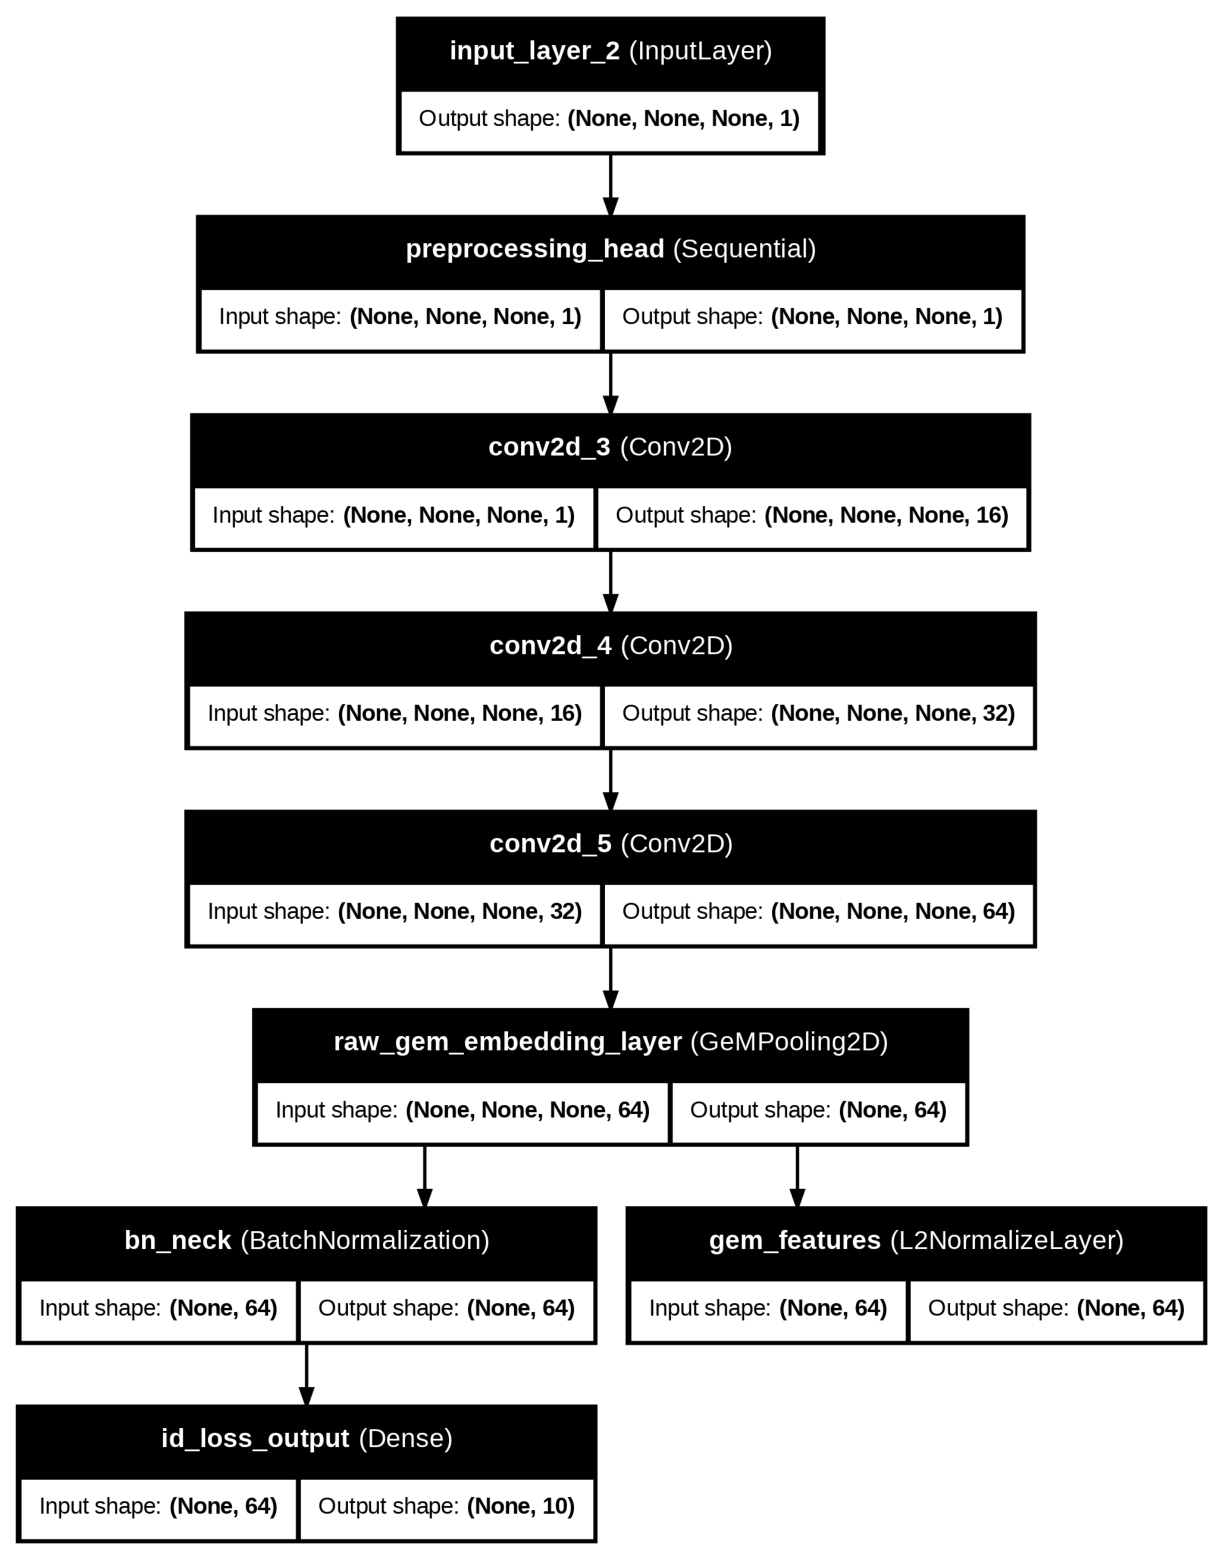

In [5]:
import matplotlib.pyplot as plt
plot_model(model, to_file='model_architecture.png', show_shapes=True, show_layer_names=True)
img = plt.imread('model_architecture.png')
plt.figure(figsize=(20, 20))
plt.imshow(img)
plt.axis('off')
plt.show()

In [6]:
import tensorflow as tf

# 1. Load the model
# We use custom_object_scope so Keras knows how to reconstruct your custom class
model_path = "/content/emnist_best_model.keras"

custom_objects = {'GeMPooling2D': GeMPooling2D, 'TripletSemiHardLoss': TripletSemiHardLoss}

with tf.keras.utils.custom_object_scope(custom_objects):
    loaded_model = tf.keras.models.load_model(model_path)

    print("✅ Model loaded successfully with all custom objects!")

    # 2. Extract the loss configuration
    # In a multi-output model, model.loss is a dictionary
    try:
        # Access the specific loss object for the gem_features output
        triplet_loss_instance = loaded_model.loss['gem_features']

        # Retrieve the margin from the restored object
        stored_margin = triplet_loss_instance.margin

        print(f"--- Verification Success ---")
        print(f"Stored Margin value: {stored_margin}")

        # Also check the internal Keras config dictionary
        config = triplet_loss_instance.get_config()
        print(f"Serialized Config: {config}")

        if stored_margin == 0.3:
            print("✅ The margin was stored and restored correctly.")
        else:
            print("❌ Margin mismatch detected.")

    except KeyError:
        print("Error: Could not find 'gem_features' in the model's loss dictionary.")

✅ Model loaded successfully with all custom objects!
--- Verification Success ---
Stored Margin value: 0.3
Serialized Config: {'name': 'triplet_loss', 'reduction': 'sum_over_batch_size', 'margin': 0.3}
✅ The margin was stored and restored correctly.


In [8]:
# Access the BatchNormalization 'neck' layer
bn_layer = loaded_model.get_layer('bn_neck')

# Check the learned moving mean and moving variance
# Note the correct attribute name: moving_variance
print(f"BN Neck Mean (first 5 channels): {bn_layer.moving_mean.numpy()[:5]}")
print(f"BN Neck Variance (first 5 channels): {bn_layer.moving_variance.numpy()[:5]}")

BN Neck Mean (first 5 channels): [0.21293762 0.25068167 0.1851694  0.10128886 0.13513441]
BN Neck Variance (first 5 channels): [0.00671371 0.01218675 0.00422104 0.00810753 0.00515046]


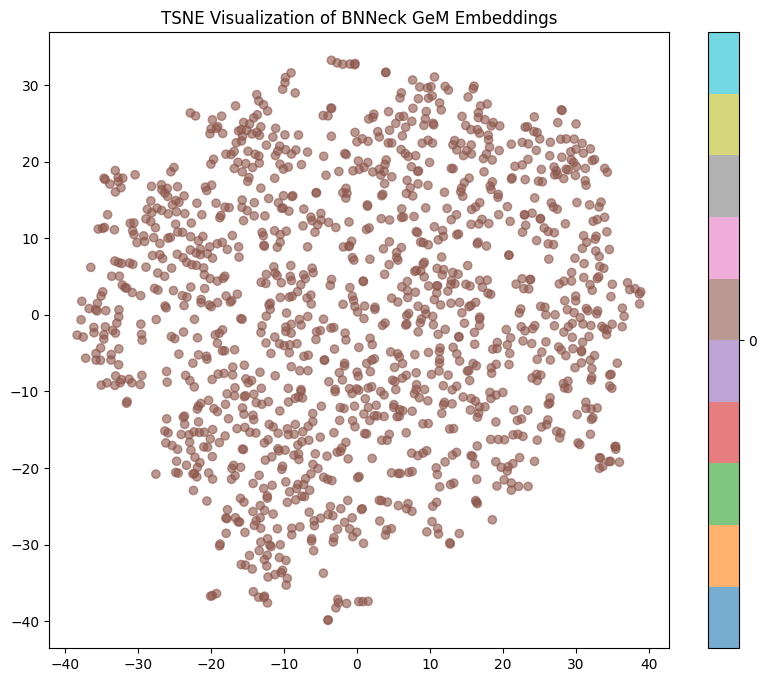

In [10]:
"""
What to look for in the plot

Tight Clusters:
Indicates high intra-class similarity.

Wide Gaps:
Indicates high inter-class variance (the result of the Triplet Loss).

Overlapping Points:
If digits like '4' and '9' overlap, it suggests the model needs more training
or a higher margin to distinguish those specific features.
"""

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

def plot_tsne_embeddings(model, dataset, num_batches=10):
    embeddings = []
    labels = []

    for i, (images, labs_dict) in enumerate(dataset):
        if i >= num_batches: break

        # model.predict returns a list: [gem_features, id_loss_output]
        preds = model.predict(images, verbose=0)

        # CHANGE: Use index 0 for gem_features (L2-normalized embeddings)
        emb = preds[0]

        embeddings.append(emb)
        # Extract the integer label from the dictionary
        labels.append(labs_dict['id_loss_output'].numpy())

    embeddings = np.vstack(embeddings)
    labels = np.concatenate(labels)

    # ... (rest of the TSNE logic remains the same)
    tsne = TSNE(n_components=2, random_state=42)
    embeddings_2d = tsne.fit_transform(embeddings)

    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
                         c=labels, cmap='tab10', alpha=0.6)
    plt.colorbar(scatter, ticks=range(10))
    plt.title("TSNE Visualization of BNNeck GeM Embeddings")
    plt.show()

# Run the visualization
plot_tsne_embeddings(loaded_model, test_data)

Searching for a diverse batch of images...
✅ Success! Found 3 unique classes in the batch.


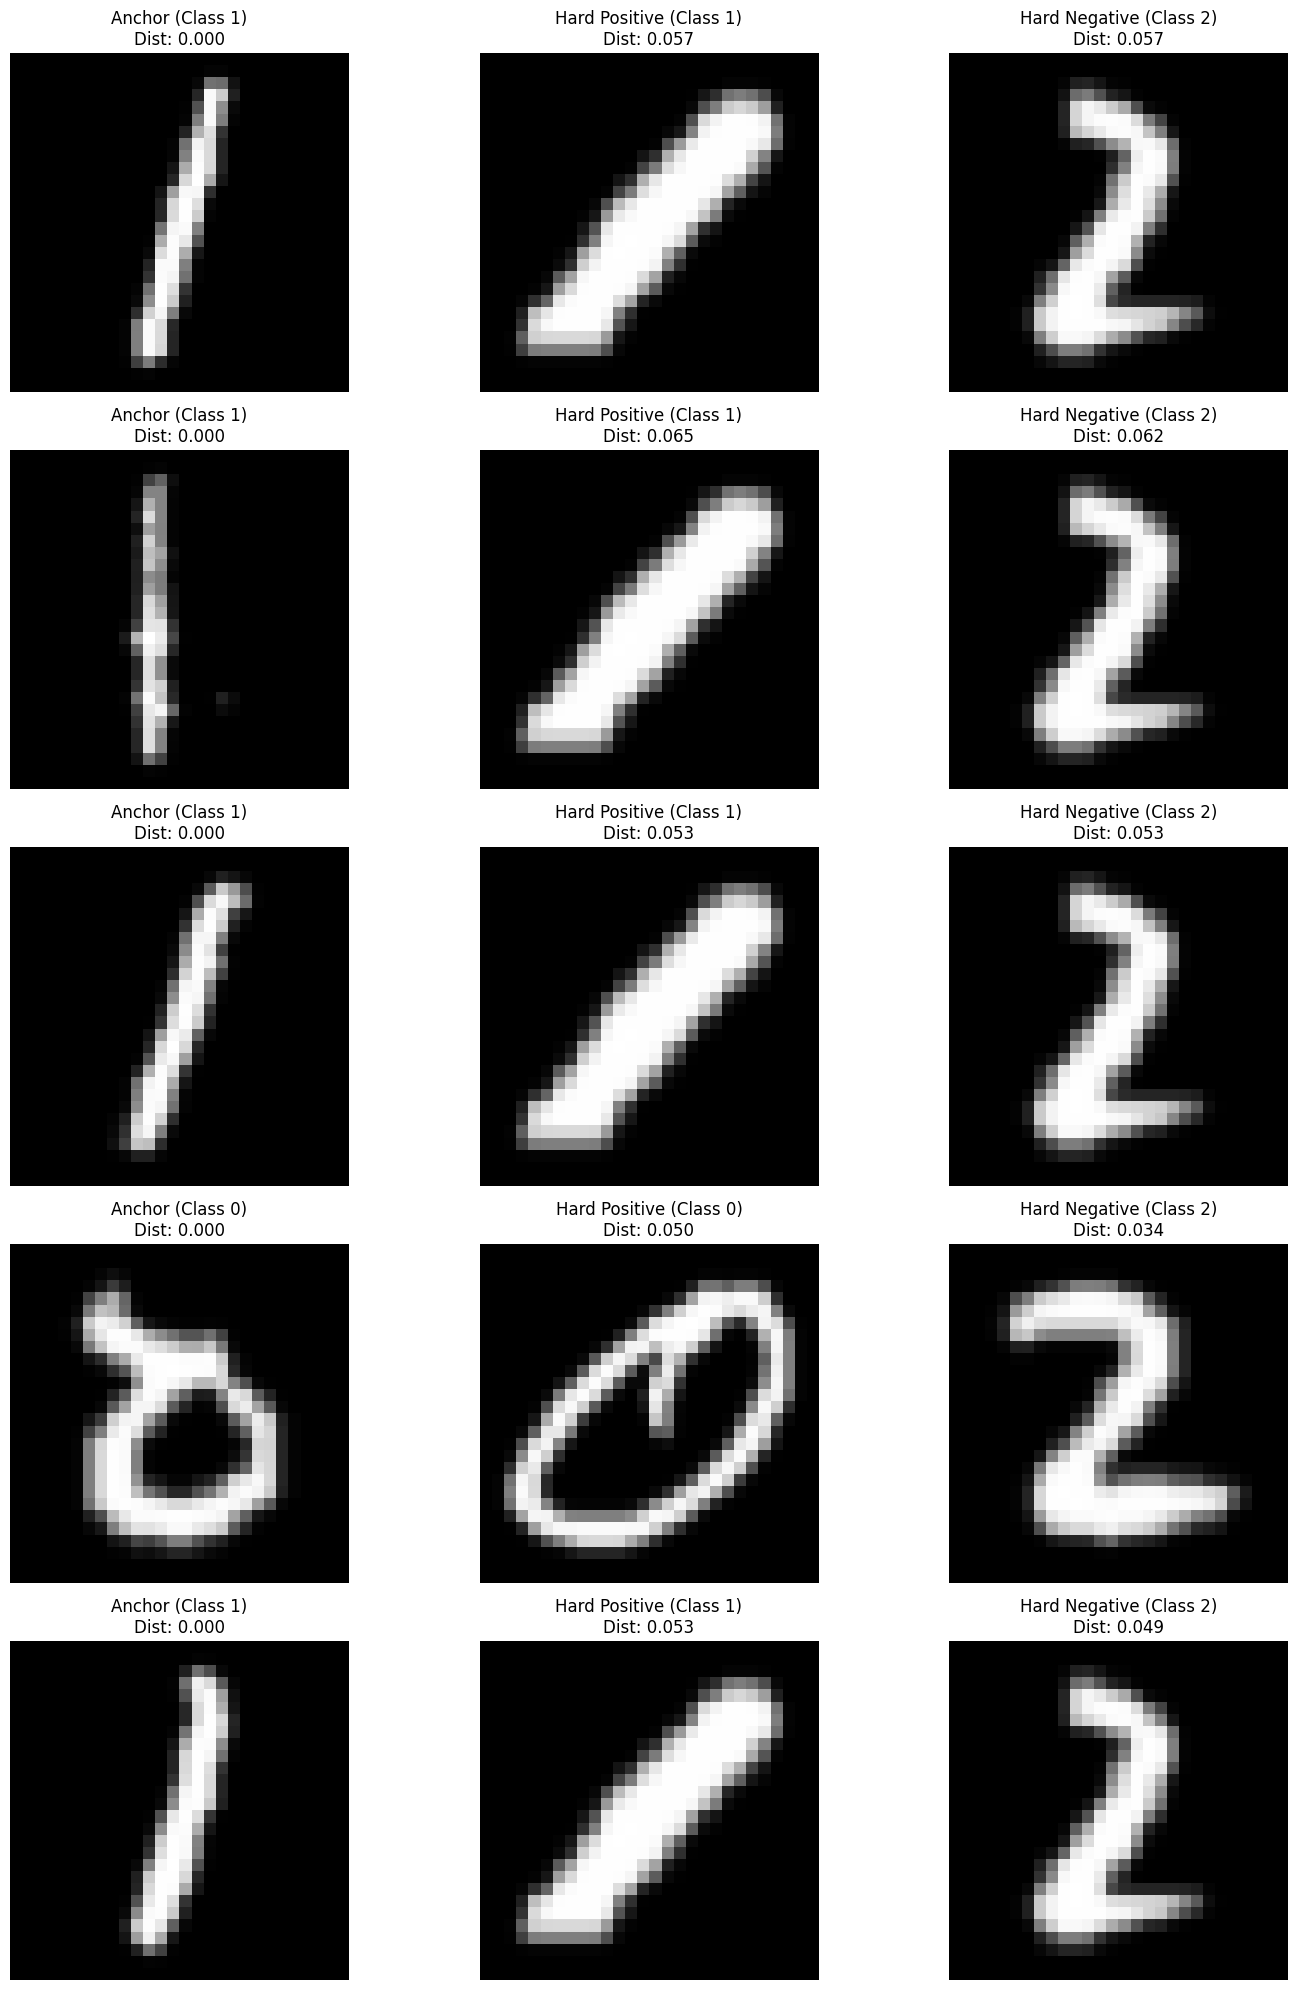

In [14]:
"""
How to Interpret the ResultsHard Positive Distance > 0.3: If the distance to the "Hard Pos"
is greater than your margin ($0.3$), the model is failing to group those similar images together.
This often happens with digits that have unusual stroke widths or rotations.Hard Negative Distance
< 0.3: If a "Hard Neg" is very close to the anchor (low distance), the model is confusing two different
classes. Look for similarities between '4' and '9' or '5' and '6'.Success Indicator: A "healthy" model
should show a Hard Positive distance that is significantly smaller than the Hard Negative distance.

Why this Validates your BNNeckThis?
visualization looks at the Metric Branch of your architecture (before the BNNeck).
By seeing exactly which images are close in the embedding space, you are verifying
if the Backbone → GeM → L2Normalize flow is creating a discriminative space where "identity"
(digit class) is the primary feature, which is the core goal of the BNNeck design.
"""

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

def visualize_hard_triplets_final(model, dataset, num_anchors=5):
    found_diverse_batch = False

    # 1. More aggressive shuffling to break class-ordering in folders
    # We unbatch, shuffle with a large buffer, and take a large batch (128)
    print("Searching for a diverse batch of images...")

    # Try up to 10 times to find a batch with multiple classes
    for attempt in range(10):
        diverse_sample = dataset.unbatch().shuffle(10000).batch(128).take(1)

        for images, labels_dict in diverse_sample:
            labels = labels_dict['id_loss_output'].numpy().flatten()
            unique_classes = np.unique(labels)

            if len(unique_classes) < 2:
                continue

            found_diverse_batch = True
            print(f"✅ Success! Found {len(unique_classes)} unique classes in the batch.")

            # 2. Extract Embeddings (Index 0 is gem_features/L2 branch)
            preds = model.predict(images, verbose=0)
            embeddings = preds[0]

            # 3. Calculate Euclidean Distance Matrix
            dot_product = np.dot(embeddings, embeddings.T)
            square_norm = np.diag(dot_product)
            distances = np.maximum(square_norm[:, None] - 2.0 * dot_product + square_norm[None, :], 0.0)
            distances = np.sqrt(distances)

            plt.figure(figsize=(15, num_anchors * 4))

            found_count = 0
            for i in range(len(labels)):
                if found_count >= num_anchors: break

                anchor_label = labels[i]
                mask_pos = (labels == anchor_label)
                mask_neg = (labels != anchor_label)

                # Verify we have at least one other image of the same class
                # and at least one image of a different class
                if np.sum(mask_pos) < 2 or np.sum(mask_neg) == 0:
                    continue

                # Hardest Positive: Max distance to same-class image (ignore self)
                pos_indices = np.where(mask_pos)[0]
                pos_dists = distances[i][mask_pos]
                pos_dists[np.where(pos_indices == i)[0]] = -1 # Ignore self
                hard_pos_idx = pos_indices[np.argmax(pos_dists)]

                # Hardest Negative: Min distance to different-class image
                neg_indices = np.where(mask_neg)[0]
                neg_dists = distances[i][mask_neg]
                hard_neg_idx = neg_indices[np.argmin(neg_dists)]

                # 4. Plotting
                triplet_idx = [i, hard_pos_idx, hard_neg_idx]
                titles = ['Anchor', 'Hard Positive', 'Hard Negative']

                for col, idx in enumerate(triplet_idx):
                    plt.subplot(num_anchors, 3, found_count * 3 + col + 1)
                    plt.imshow(images[idx].numpy().squeeze(), cmap='gray')
                    plt.title(f"{titles[col]} (Class {labels[idx]})\nDist: {distances[i, idx]:.3f}")
                    plt.axis('off')

                found_count += 1

            plt.tight_layout()
            plt.show()
            return # Exit after one successful plot

    print("❌ Could not find a diverse batch after 10 attempts. Check if your test_data is correctly loaded.")

# Run the visualization
visualize_hard_triplets_final(loaded_model, test_data)